# OpenCabinet Policy Training (Google Colab + A100)

Train a behavior-cloning policy for the RoboCasa OpenCabinet task using
demonstration data stored on Google Drive.

**Before running:** Go to *Runtime > Change runtime type > GPU (A100).*

## 1. Setup

In [2]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected! Go to Runtime > Change runtime type > GPU")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU memory: 42.4 GB


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q pyarrow matplotlib

In [5]:
import os

DRIVE_ROOT = "/content/drive/.shortcut-targets-by-id/1o9yPiQvIuOgStlQNEHu1OPd6qRrwGMcJ/cs188_data"

print("Google Drive data directory contents:")
for item in sorted(os.listdir(DRIVE_ROOT)):
    full = os.path.join(DRIVE_ROOT, item)
    tag = "[dir]" if os.path.isdir(full) else f"[file, {os.path.getsize(full)/1e6:.1f} MB]"
    print(f"  {tag}  {item}")

Google Drive data directory contents:
  [dir]  checkpoints
  [dir]  data
  [dir]  videos


## 2. Discover & Load Dataset

The dataset is in **LeRobot format** on Google Drive:
- `data/chunk-000/episode_XXXXXX.parquet` — state-action pairs per episode
- `videos/chunk-000/` — MP4 camera videos per episode (3 camera views)

Each parquet row contains:
- `observation.state` (16-dim): base pos [3], base quat [4], base-to-eef pos [3], base-to-eef quat [4], gripper qpos [2]
- `action` (12-dim): ee delta pos [3], ee delta rot [3], gripper [1], base motion [3], torso [1], control mode [1]

In [7]:
def find_dataset_root(base_path):
    """Walk the Drive folder to find a directory containing data/chunk-000/*.parquet."""
    for root, dirs, files in os.walk(base_path):
        if 'data' in dirs:
            chunk_dir = os.path.join(root, 'data', 'chunk-000')
            if os.path.isdir(chunk_dir):
                parquets = [f for f in os.listdir(chunk_dir) if f.endswith('.parquet')]
                if parquets:
                    return root
    return None

DATASET_ROOT = find_dataset_root(DRIVE_ROOT)

if DATASET_ROOT is None:
    print("ERROR: Could not find dataset (expected data/chunk-000/*.parquet).")
    print("Listing full tree:")
    for root, dirs, files in os.walk(DRIVE_ROOT):
        level = root.replace(DRIVE_ROOT, '').count(os.sep)
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 4:
            for f in files[:5]:
                print(f"{indent}  {f}")
            if len(files) > 5:
                print(f"{indent}  ... ({len(files)} files)")
else:
    print(f"Dataset root: {DATASET_ROOT}")
    print()
    for item in sorted(os.listdir(DATASET_ROOT)):
        full = os.path.join(DATASET_ROOT, item)
        print(f"  {item}/" if os.path.isdir(full) else f"  {item}")

Dataset root: /content/drive/.shortcut-targets-by-id/1o9yPiQvIuOgStlQNEHu1OPd6qRrwGMcJ/cs188_data

  checkpoints/
  data/
  videos/


In [8]:
import json
import pyarrow.parquet as pq

info_path = os.path.join(DATASET_ROOT, 'meta', 'info.json')
if os.path.exists(info_path):
    with open(info_path) as f:
        info = json.load(f)
    print(f"Total episodes:  {info['total_episodes']}")
    print(f"Total frames:    {info['total_frames']}")
    print(f"FPS:             {info['fps']}")
    print(f"Robot:           {info['robot_type']}")
    print(f"\nFeatures:")
    for k, v in info['features'].items():
        if 'shape' in v:
            print(f"  {k}: shape={v['shape']}, dtype={v['dtype']}")
else:
    print("No meta/info.json found — inspecting parquet files directly.")
    chunk_dir = os.path.join(DATASET_ROOT, 'data', 'chunk-000')
    parquet_files = sorted(f for f in os.listdir(chunk_dir) if f.endswith('.parquet'))
    print(f"Episodes (parquet files): {len(parquet_files)}")

    sample = pq.read_table(os.path.join(chunk_dir, parquet_files[0])).to_pandas()
    print(f"Sample episode rows: {len(sample)}")
    print(f"\nColumns:")
    for c in sample.columns:
        val = sample[c].iloc[0]
        if hasattr(val, 'shape'):
            print(f"  {c}: shape={val.shape}, dtype={val.dtype}")
        else:
            print(f"  {c}: type={type(val).__name__}, sample={val}")

No meta/info.json found — inspecting parquet files directly.
Episodes (parquet files): 107
Sample episode rows: 169

Columns:
  annotation.human.task_description: shape=(), dtype=int64
  annotation.human.task_name: shape=(), dtype=int64
  observation.state: shape=(16,), dtype=float64
  action: shape=(12,), dtype=float64
  next.reward: shape=(), dtype=float32
  next.done: shape=(), dtype=bool
  timestamp: shape=(), dtype=float32
  frame_index: shape=(), dtype=int64
  episode_index: shape=(), dtype=int64
  index: shape=(), dtype=int64
  task_index: shape=(), dtype=int64


In [9]:
import numpy as np

def load_dataset(dataset_root, max_episodes=None):
    """Load all state-action pairs from LeRobot parquet files."""
    chunk_dir = os.path.join(dataset_root, 'data', 'chunk-000')
    parquet_files = sorted(f for f in os.listdir(chunk_dir) if f.endswith('.parquet'))

    if max_episodes is not None:
        parquet_files = parquet_files[:max_episodes]

    all_states, all_actions, episode_boundaries = [], [], [0]

    for pf in parquet_files:
        df = pq.read_table(os.path.join(chunk_dir, pf)).to_pandas()

        for _, row in df.iterrows():
            state = np.array(row['observation.state'], dtype=np.float32)
            action = np.array(row['action'], dtype=np.float32)
            all_states.append(state)
            all_actions.append(action)

        episode_boundaries.append(len(all_states))

    states = np.array(all_states, dtype=np.float32)
    actions = np.array(all_actions, dtype=np.float32)

    print(f"Loaded {len(parquet_files)} episodes, {len(states)} timesteps")
    print(f"State dim:  {states.shape[-1]}")
    print(f"Action dim: {actions.shape[-1]}")
    return states, actions, episode_boundaries

states, actions, ep_bounds = load_dataset(DATASET_ROOT)

Loaded 107 episodes, 37492 timesteps
State dim:  16
Action dim: 12


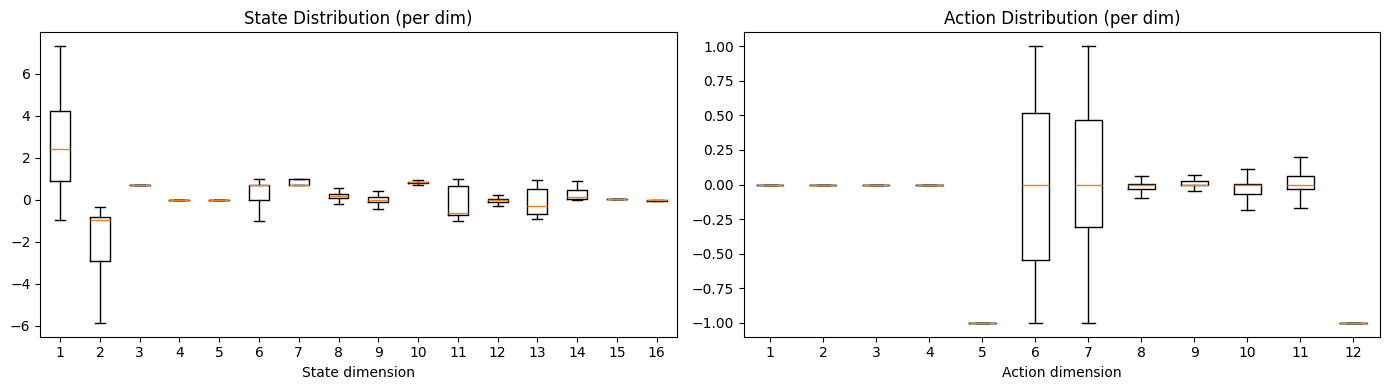

Episode lengths — min: 169, max: 618, mean: 350, median: 375


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].set_title("State Distribution (per dim)")
axes[0].boxplot([states[:, i] for i in range(states.shape[1])], showfliers=False)
axes[0].set_xlabel("State dimension")

axes[1].set_title("Action Distribution (per dim)")
axes[1].boxplot([actions[:, i] for i in range(actions.shape[1])], showfliers=False)
axes[1].set_xlabel("Action dimension")

plt.tight_layout()
plt.show()

ep_lengths = [ep_bounds[i+1] - ep_bounds[i] for i in range(len(ep_bounds)-1)]
print(f"Episode lengths — min: {min(ep_lengths)}, max: {max(ep_lengths)}, "
      f"mean: {np.mean(ep_lengths):.0f}, median: {np.median(ep_lengths):.0f}")

## 3. PyTorch Dataset & DataLoader

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

class CabinetDemoDataset(Dataset):
    def __init__(self, states, actions):
        self.states = torch.from_numpy(states)
        self.actions = torch.from_numpy(actions)

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        return self.states[idx], self.actions[idx]


full_dataset = CabinetDemoDataset(states, actions)

val_size = int(0.1 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size],
                                generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

BATCH_SIZE = 256

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

Train: 33743, Val: 3749


## 4. Define Policy Network

We define two models:
1. **SimplePolicy** — small 3-layer MLP baseline (same as `06_train_policy.py`)
2. **ImprovedPolicy** — deeper residual MLP with layer norm, dropout, and optional action chunking

In [12]:
class SimplePolicy(nn.Module):
    """Baseline 3-layer MLP from 06_train_policy.py."""
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, state):
        return self.net(state)


class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.block(x)


class ImprovedPolicy(nn.Module):
    """
    Deeper residual MLP with layer norm and dropout.

    When chunk_size > 1 the model predicts chunk_size consecutive actions at
    once (action chunking), which can produce smoother trajectories.
    """
    def __init__(self, state_dim, action_dim, hidden_dim=512,
                 n_blocks=6, dropout=0.1, chunk_size=1):
        super().__init__()
        self.chunk_size = chunk_size
        self.action_dim = action_dim

        self.input_proj = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.GELU(),
        )
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim, dropout) for _ in range(n_blocks)]
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, action_dim * chunk_size),
            nn.Tanh(),
        )

    def forward(self, state):
        x = self.input_proj(state)
        x = self.blocks(x)
        out = self.head(x)
        if self.chunk_size > 1:
            out = out.view(-1, self.chunk_size, self.action_dim)
        return out

## 5. Training Loop

In [13]:
# ── Hyperparameters ──────────────────────────────────────────
CONFIG = {
    "model": "improved",  # "simple" or "improved"
    "hidden_dim": 512,
    "n_blocks": 6,
    "dropout": 0.1,
    "epochs": 200,
    "lr": 3e-4,
    "weight_decay": 1e-5,
    "lr_warmup_epochs": 10,
}

STATE_DIM = states.shape[-1]   # 16
ACTION_DIM = actions.shape[-1] # 12

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if CONFIG["model"] == "simple":
    model = SimplePolicy(STATE_DIM, ACTION_DIM, hidden_dim=CONFIG["hidden_dim"]).to(device)
else:
    model = ImprovedPolicy(
        STATE_DIM, ACTION_DIM,
        hidden_dim=CONFIG["hidden_dim"],
        n_blocks=CONFIG["n_blocks"],
        dropout=CONFIG["dropout"],
    ).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model: {CONFIG['model']}, Parameters: {num_params:,}")
print(model)

Device: cuda
Model: improved, Parameters: 3,173,900
ImprovedPolicy(
  (input_proj): Sequential(
    (0): Linear(in_features=16, out_features=512, bias=True)
    (1): GELU(approximate='none')
  )
  (blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=512, out_features=512, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.1, inplace=False)
        (4): Linear(in_features=512, out_features=512, bias=True)
        (5): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=512, out_features=512, bias=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.1, inplace=False)
        (4): Linear(in_features=512, out_features=512, bias=True)
        (5): Dropout(p=0.1, inplace=False)
      )
    )
    (

In [14]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"],
                              weight_decay=CONFIG["weight_decay"])

warmup_epochs = CONFIG["lr_warmup_epochs"]
total_epochs = CONFIG["epochs"]

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return epoch / max(warmup_epochs, 1)
    progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, n_batches = 0.0, 0
    for s, a in loader:
        s, a = s.to(device), a.to(device)
        pred = model(s)
        loss = nn.functional.mse_loss(pred, a)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss, n_batches = 0.0, 0
    for s, a in loader:
        s, a = s.to(device), a.to(device)
        pred = model(s)
        loss = nn.functional.mse_loss(pred, a)
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)

In [15]:
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

train_losses, val_losses, lrs = [], [], []
best_val_loss = float("inf")

print(f"Training for {CONFIG['epochs']} epochs ...")
print(f"Checkpoints → {CHECKPOINT_DIR}")
print("-" * 65)

for epoch in range(CONFIG["epochs"]):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = eval_epoch(model, val_loader, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lrs.append(optimizer.param_groups[0]["lr"])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "loss": val_loss,
            "state_dim": STATE_DIM,
            "action_dim": ACTION_DIM,
            "config": CONFIG,
        }, os.path.join(CHECKPOINT_DIR, "best_policy.pt"))

    if (epoch + 1) % 10 == 0 or epoch == 0:
        marker = " *" if val_loss <= best_val_loss else ""
        print(f"Epoch {epoch+1:4d}/{CONFIG['epochs']}  "
              f"train={train_loss:.6f}  val={val_loss:.6f}  "
              f"lr={lrs[-1]:.2e}{marker}")

# Save final checkpoint
torch.save({
    "epoch": CONFIG["epochs"],
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": train_losses[-1],
    "val_loss": val_losses[-1],
    "loss": val_losses[-1],
    "state_dim": STATE_DIM,
    "action_dim": ACTION_DIM,
    "config": CONFIG,
}, os.path.join(CHECKPOINT_DIR, "final_policy.pt"))

print("-" * 65)
print(f"Best val loss: {best_val_loss:.6f}")
print(f"Checkpoints saved to: {CHECKPOINT_DIR}")

Training for 200 epochs ...
Checkpoints → /content/drive/.shortcut-targets-by-id/1o9yPiQvIuOgStlQNEHu1OPd6qRrwGMcJ/cs188_data/checkpoints
-----------------------------------------------------------------
Epoch    1/200  train=0.432110  val=0.438900  lr=3.00e-05 *
Epoch   10/200  train=0.062374  val=0.053685  lr=3.00e-04 *
Epoch   20/200  train=0.038081  val=0.037710  lr=2.98e-04 *
Epoch   30/200  train=0.029014  val=0.026365  lr=2.92e-04 *
Epoch   40/200  train=0.023886  val=0.024241  lr=2.82e-04
Epoch   50/200  train=0.019946  val=0.018257  lr=2.68e-04 *
Epoch   60/200  train=0.018177  val=0.018213  lr=2.52e-04
Epoch   70/200  train=0.016276  val=0.015779  lr=2.32e-04
Epoch   80/200  train=0.014739  val=0.012324  lr=2.10e-04 *
Epoch   90/200  train=0.013384  val=0.011668  lr=1.87e-04 *
Epoch  100/200  train=0.012202  val=0.011936  lr=1.62e-04
Epoch  110/200  train=0.010934  val=0.010409  lr=1.38e-04
Epoch  120/200  train=0.009767  val=0.009068  lr=1.13e-04
Epoch  130/200  train=0.0089

## 6. Training Curves

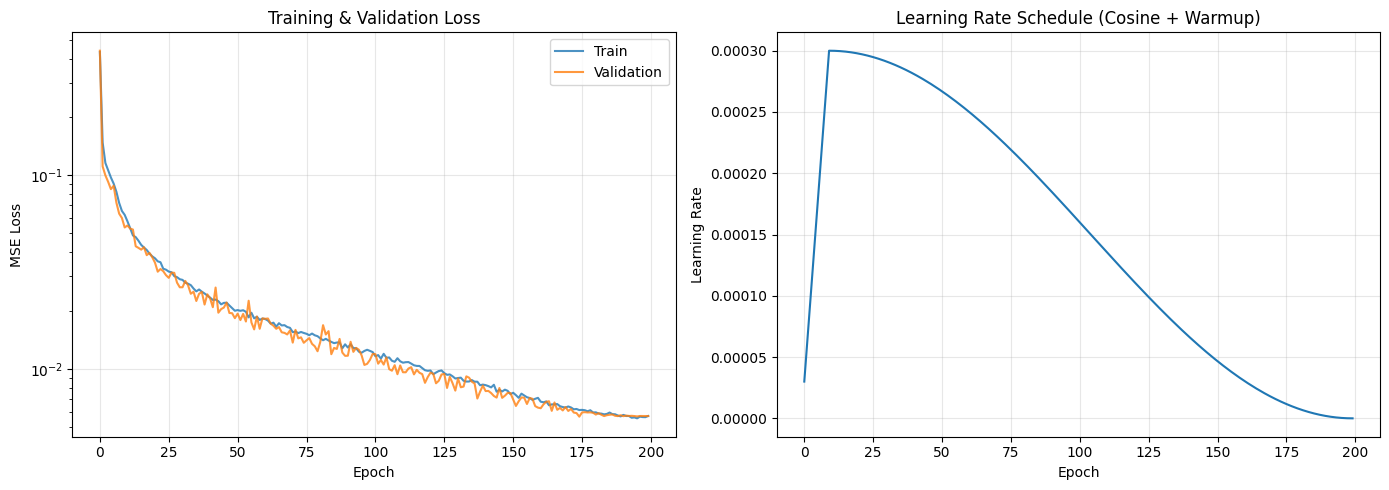

Saved training_curves.png to /content/drive/.shortcut-targets-by-id/1o9yPiQvIuOgStlQNEHu1OPd6qRrwGMcJ/cs188_data/checkpoints


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train", alpha=0.8)
ax1.plot(val_losses, label="Validation", alpha=0.8)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)

ax2.plot(lrs)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Learning Rate Schedule (Cosine + Warmup)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "training_curves.png"), dpi=150)
plt.show()
print(f"Saved training_curves.png to {CHECKPOINT_DIR}")

## 7. Inspect Predictions

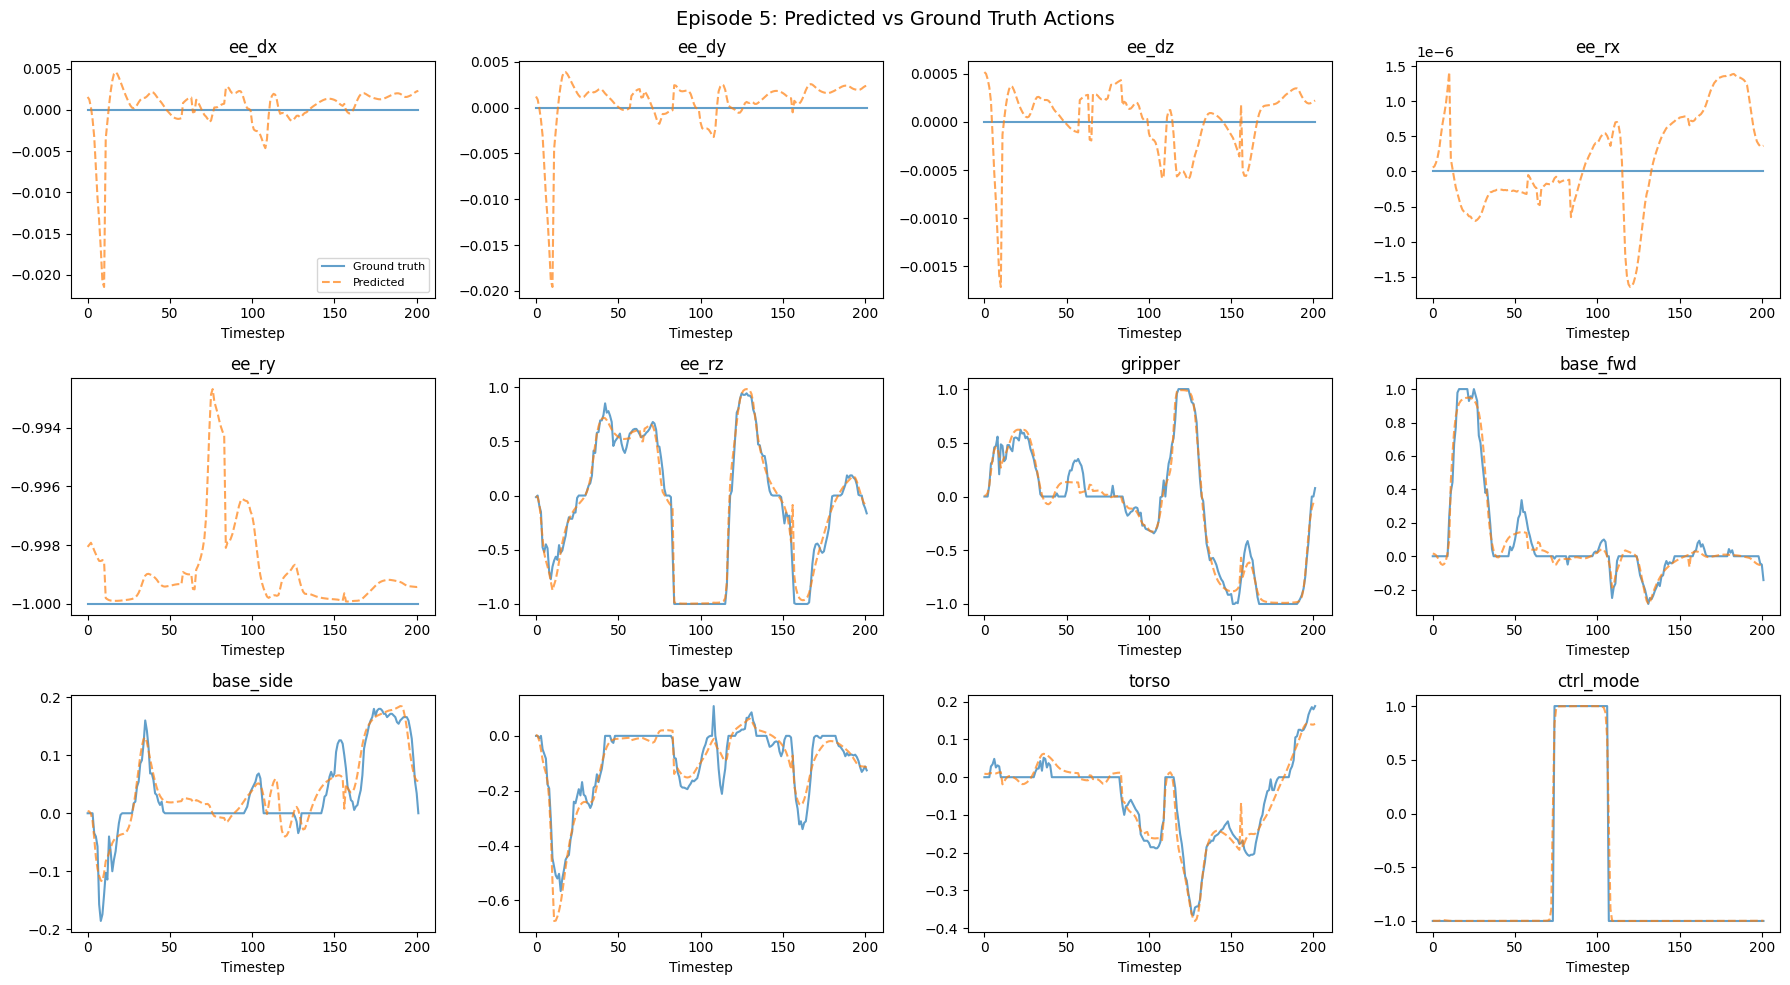

In [17]:
# Load the best checkpoint and compare predictions vs ground truth
ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "best_policy.pt"), map_location=device,
                  weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# Pick a random episode for visualization
ep_idx = 5
ep_start, ep_end = ep_bounds[ep_idx], ep_bounds[ep_idx + 1]
ep_states = torch.from_numpy(states[ep_start:ep_end]).to(device)
ep_actions_gt = actions[ep_start:ep_end]

with torch.no_grad():
    ep_actions_pred = model(ep_states).cpu().numpy()

action_labels = ["ee_dx", "ee_dy", "ee_dz", "ee_rx", "ee_ry", "ee_rz",
                 "gripper", "base_fwd", "base_side", "base_yaw", "torso", "ctrl_mode"]

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for i, ax in enumerate(axes.flat):
    if i >= ACTION_DIM:
        ax.axis("off")
        continue
    ax.plot(ep_actions_gt[:, i], label="Ground truth", alpha=0.7)
    ax.plot(ep_actions_pred[:, i], label="Predicted", alpha=0.7, linestyle="--")
    ax.set_title(action_labels[i] if i < len(action_labels) else f"dim {i}")
    ax.set_xlabel("Timestep")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(f"Episode {ep_idx}: Predicted vs Ground Truth Actions", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "action_comparison.png"), dpi=150)
plt.show()

## 8. Preview Demonstration Videos

In [18]:
from IPython.display import HTML
import base64

def find_video_dir(dataset_root):
    """Locate the demonstration video directory."""
    candidates = [
        os.path.join(dataset_root, 'videos', 'chunk-000'),
        os.path.join(dataset_root, '..', 'videos', 'chunk-000'),
    ]
    for c in candidates:
        if os.path.isdir(c):
            return c
    # Search more broadly
    for root, dirs, _ in os.walk(os.path.dirname(dataset_root)):
        if 'observation.images.robot0_agentview_left' in dirs:
            return root
    return None

video_chunk_dir = find_video_dir(DATASET_ROOT)

if video_chunk_dir:
    cam_dirs = [d for d in os.listdir(video_chunk_dir) if os.path.isdir(os.path.join(video_chunk_dir, d))]
    print(f"Video directory: {video_chunk_dir}")
    print(f"Camera views: {cam_dirs}")

    # Show first episode from left camera
    cam = cam_dirs[0] if cam_dirs else None
    if cam:
        vids = sorted(os.listdir(os.path.join(video_chunk_dir, cam)))[:1]
        if vids:
            vid_path = os.path.join(video_chunk_dir, cam, vids[0])
            with open(vid_path, 'rb') as f:
                vid_data = base64.b64encode(f.read()).decode()
            print(f"\nShowing: {cam}/{vids[0]}")
            display(HTML(f'<video controls width="400"><source src="data:video/mp4;base64,{vid_data}" type="video/mp4"></video>'))
else:
    print("No video directory found. Videos may not have been uploaded to Drive.")
    print("This is fine — training only uses the parquet state-action data.")

Video directory: /content/drive/.shortcut-targets-by-id/1o9yPiQvIuOgStlQNEHu1OPd6qRrwGMcJ/cs188_data/videos/chunk-000
Camera views: ['observation.images.robot0_agentview_left', 'observation.images.robot0_eye_in_hand', 'observation.images.robot0_agentview_right']

Showing: observation.images.robot0_agentview_left/episode_000000.mp4


## 9. Summary & Next Steps

The trained checkpoints are saved to Google Drive at:
```
cs188_data/checkpoints/
├── best_policy.pt
├── final_policy.pt
├── training_curves.png
└── action_comparison.png
```

To evaluate locally, copy the checkpoint to your machine and run:
```bash
python 07_evaluate_policy.py --checkpoint path/to/best_policy.pt
```

### Ideas to improve the policy
- **Diffusion Policy**: Replace MSE regression with a diffusion-based action generator to handle multi-modal demonstrations
- **DAgger**: Use `03_teleop_collect_demos.py --dagger` to collect online corrections and retrain
- **Action Chunking**: Set `chunk_size > 1` in `ImprovedPolicy` and modify the dataset to return action windows
- **GMM output head**: Replace Tanh output with a Gaussian Mixture Model to capture multi-modality

In [ ]:
print(f"Best checkpoint: {os.path.join(CHECKPOINT_DIR, 'best_policy.pt')}")
print(f"Best val loss:   {best_val_loss:.6f}")
print(f"State dim: {STATE_DIM}, Action dim: {ACTION_DIM}")
print(f"\nTo evaluate locally:")
print(f"  python 07_evaluate_policy.py --checkpoint best_policy.pt")